# CUT Model

In [3]:
from Trainers.CUTtrain import CUTTrainer

cfg = { 
       "data": {
            "low_res_dir": "Data/Low_resolution/CFRP_60_low",
            "high_res_dir": "Data/High_resolution/CFRP_60_high",
            "paired": False,
        },
        "training": {
            "batch_size": 4,      # smaller batch
            "num_epochs": 50,
            "lr": 2e-4,
            "beta1": 0.5,
            "beta2": 0.999,
            "num_workers": 0,     # safer/faster on Windows
        },
        "model": {
            "input_nc": 3,
            "output_nc": 3,
            "ngf": 32,            # was 64
            "ndf": 32,            # was 64
        },
        "cut": {
            "lambda_GAN": 1.0,
            "lambda_NCE": 1.0,    # unused in simplified mode
            "lambda_idt": 0.5,
            "num_patches": 64,    # doesn’t matter much if simplified
            "nce_layers": "4,8",
            "nce_T": 0.07,
            "use_simplified": False,    # KEY: turns off heavy NCE
            "checkpoints_dir": "./checkpoints",
            "name": "cut_experiment_fast",
            "direction": "AtoB",
        }
}

cuttrainer = CUTTrainer(cfg)
cuttrainer.train()
# print("model.use_simplified:", trainer.model.use_simplified)
# print("G device:", next(trainer.model.netG.parameters()).device)
# print("real_A device (after one batch):")
# batch = next(iter(trainer.dataloader))
# trainer.model.set_input({
#     "A": batch["low_res"].to(trainer.model.device),
#     "B": batch["high_res"].to(trainer.model.device),
#     "A_paths": batch["low_path"],
#     "B_paths": batch["high_path"],
# })
# print(trainer.model.real_A.device)


Using device: cuda
Epoch [1/50] G_loss: 8.2887, D_loss: 1.6170
Epoch [2/50] G_loss: 7.8866, D_loss: 1.9169
Epoch [3/50] G_loss: 6.5075, D_loss: 1.1181
Epoch [4/50] G_loss: 5.8933, D_loss: 0.3774
Epoch [5/50] G_loss: 5.7839, D_loss: 0.2980
Epoch [6/50] G_loss: 5.2108, D_loss: 0.1294
Epoch [7/50] G_loss: 6.2207, D_loss: 0.6443
Epoch [8/50] G_loss: 5.3574, D_loss: 0.1162
Epoch [9/50] G_loss: 5.9414, D_loss: 0.3654
Epoch [10/50] G_loss: 5.5622, D_loss: 0.2098
Epoch [11/50] G_loss: 5.3345, D_loss: 0.2379
Epoch [12/50] G_loss: 5.4397, D_loss: 0.1646
Epoch [13/50] G_loss: 5.2548, D_loss: 0.2067
Epoch [14/50] G_loss: 5.9721, D_loss: 0.3301
Epoch [15/50] G_loss: 5.2786, D_loss: 0.2140
Epoch [16/50] G_loss: 5.2533, D_loss: 0.6498
Epoch [17/50] G_loss: 5.3579, D_loss: 0.1407
Epoch [18/50] G_loss: 5.2700, D_loss: 0.2089
Epoch [19/50] G_loss: 5.3290, D_loss: 0.1715
Epoch [20/50] G_loss: 5.4305, D_loss: 0.1857
Epoch [21/50] G_loss: 5.2381, D_loss: 0.1838
Epoch [22/50] G_loss: 5.3333, D_loss: 0.1304


In [4]:
cuttrainer.model.eval()
batch = next(iter(cuttrainer.dataloader))
cuttrainer.model.set_input({
    "A": batch["low_res"].to(cuttrainer.model.device),
    "B": batch["high_res"].to(cuttrainer.model.device),
    "A_paths": batch["low_path"],
    "B_paths": batch["high_path"],
})
cuttrainer.model.test()
visuals = cuttrainer.model.get_current_visuals()

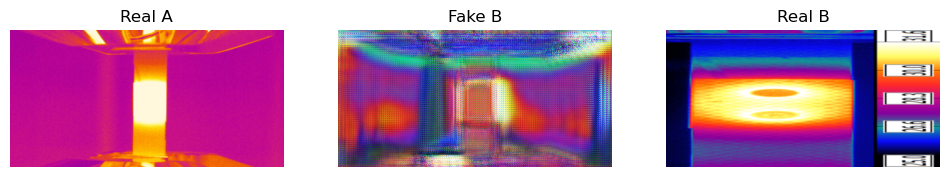

In [5]:
import torch
import matplotlib.pyplot as plt

def tensor_to_image(t):
    # t: [B, C, H, W] from model
    img = t[0].detach().cpu()          # first in batch
    img = (img * 0.5) + 0.5            # [-1,1] -> [0,1]
    if img.shape[0] == 1:
        img = img.squeeze(0)           # [1,H,W] -> [H,W] for grayscale
        cmap = "gray"
    else:
        img = img.permute(1, 2, 0)     # [C,H,W] -> [H,W,C]
        cmap = None
    return img, cmap

visuals = cuttrainer.model.get_current_visuals()

real_A_img, cmap_A = tensor_to_image(visuals["real_A"])
fake_B_img, cmap_B = tensor_to_image(visuals["fake_B"])
real_B_img, cmap_Br = tensor_to_image(visuals["real_B"])

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(real_A_img, cmap=cmap_A); plt.title("Real A"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(fake_B_img, cmap=cmap_B); plt.title("Fake B"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(real_B_img, cmap=cmap_Br); plt.title("Real B"); plt.axis("off")
plt.show()


# WGAN Model

In [6]:
from Trainers.WGANtrain import WGANTrainer

wgan_config = {
    "data": {
        "low_res_dir": "Data/Low_resolution/CFRP_60_low",
        "high_res_dir": "Data/High_resolution/CFRP_60_high",
        "paired": False,
    },
    "training": {
        "batch_size": 4,
        "num_epochs": 50,
        "lr": 1e-4,
        "beta1": 0.5,
        "beta2": 0.9,
        "num_workers": 0,
    },
    "model": {
        "input_nc": 3,
        "output_nc": 3,
        "ngf": 32,
        "ndf": 32,
    },
    "wgan": {
        "lambda_L1": 10.0,
        "lambda_gp": 10.0,
        "n_critic": 5,
        # "gpu_ids": [0],
    },
}

wgantrainer = WGANTrainer(wgan_config)
wgantrainer.train()


Using device: cuda
Starting WGAN-GP training...
Epoch [1/50]
Epoch [1/50] G: 15.9286 (adv 10.0069, L1 5.9217), D: -24.8354, GP: 0.0339
Epoch [2/50]
Epoch [2/50] G: 22.5157 (adv 17.1839, L1 5.3318), D: -38.6567, GP: 0.0469
Epoch [3/50]
Epoch [3/50] G: 28.6218 (adv 23.5808, L1 5.0409), D: -55.3502, GP: 0.0979
Epoch [4/50]
Epoch [4/50] G: 33.7911 (adv 29.2071, L1 4.5840), D: -71.8104, GP: 0.0277
Epoch [5/50]
Epoch [5/50] G: 38.4573 (adv 33.5754, L1 4.8819), D: -85.1249, GP: 0.3793
Epoch [6/50]
Epoch [6/50] G: 49.6791 (adv 45.1009, L1 4.5782), D: -105.3503, GP: 0.2681
Epoch [7/50]
Epoch [7/50] G: 51.7811 (adv 47.3299, L1 4.4511), D: -121.4499, GP: 0.0933
Epoch [8/50]
Epoch [8/50] G: 60.8880 (adv 56.4393, L1 4.4487), D: -124.4477, GP: 1.1409
Epoch [9/50]
Epoch [9/50] G: 67.4710 (adv 63.2333, L1 4.2377), D: -153.9256, GP: 0.1856
Epoch [10/50]
Epoch [10/50] G: 75.8228 (adv 71.8087, L1 4.0141), D: -172.2256, GP: 0.2239
Epoch [11/50]
Epoch [11/50] G: 83.7506 (adv 79.6690, L1 4.0816), D: -189.28

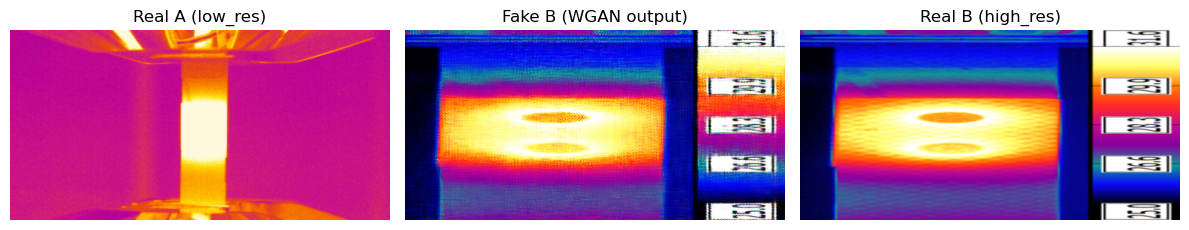

In [7]:
import torch
import matplotlib.pyplot as plt

def tensor_to_image(t):
    # t: [B, C, H, W] in [-1,1]
    img = t[0].detach().cpu()
    img = (img * 0.5) + 0.5          # [-1,1] -> [0,1]
    if img.shape[0] == 1:
        img = img.squeeze(0)         # [1,H,W] -> [H,W]
        cmap = "gray"
    else:
        img = img.permute(1, 2, 0)   # [C,H,W] -> [H,W,C]
        cmap = None
    return img, cmap

# switch to eval mode
wgantrainer.model.eval()

# get one batch
batch = next(iter(wgantrainer.dataloader))
wgantrainer.model.set_input(batch)

with torch.no_grad():
    wgantrainer.model.forward_G()
    real_A = wgantrainer.model.real_A
    fake_B = wgantrainer.model.fake_B
    real_B = wgantrainer.model.real_B

real_A_img, cmap_A = tensor_to_image(real_A)
fake_B_img, cmap_F = tensor_to_image(fake_B)
real_B_img, cmap_B = tensor_to_image(real_B)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(real_A_img, cmap=cmap_A)
plt.title("Real A (low_res)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(fake_B_img, cmap=cmap_F)
plt.title("Fake B (WGAN output)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(real_B_img, cmap=cmap_B)
plt.title("Real B (high_res)")
plt.axis("off")

plt.tight_layout()
plt.show()


# Super-Resolution

In [8]:
from Trainers.SRtrain import SRTrainer

sr_config = {
    "data": {
        "hr_dir": "Data/High_resolution/CFRP_60_high",
        "hr_size": (256, 512),
        "scale_factor": 4,
    },
    "training": {
        "batch_size": 4,
        "num_epochs": 50,
        "lr": 1e-4,
        "beta1": 0.9,
        "beta2": 0.999,
        "num_workers": 0,
    },
    "model": {
        "input_nc": 3,
        "output_nc": 3,
        "ngf": 32,
    },
}

srtrainer = SRTrainer(sr_config)
srtrainer.train()


Using device: cuda
Starting SR training...
Epoch [1/50]
Epoch [1/50] L1: 0.2263
Epoch [2/50]
Epoch [2/50] L1: 0.1365
Epoch [3/50]
Epoch [3/50] L1: 0.1118
Epoch [4/50]
Epoch [4/50] L1: 0.1003
Epoch [5/50]
Epoch [5/50] L1: 0.0936
Epoch [6/50]
Epoch [6/50] L1: 0.0887
Epoch [7/50]
Epoch [7/50] L1: 0.0867
Epoch [8/50]
Epoch [8/50] L1: 0.0819
Epoch [9/50]
Epoch [9/50] L1: 0.0797
Epoch [10/50]
Epoch [10/50] L1: 0.0775
Epoch [11/50]
Epoch [11/50] L1: 0.0751
Epoch [12/50]
Epoch [12/50] L1: 0.0741
Epoch [13/50]
Epoch [13/50] L1: 0.0727
Epoch [14/50]
Epoch [14/50] L1: 0.0706
Epoch [15/50]
Epoch [15/50] L1: 0.0688
Epoch [16/50]
Epoch [16/50] L1: 0.0679
Epoch [17/50]
Epoch [17/50] L1: 0.0671
Epoch [18/50]
Epoch [18/50] L1: 0.0654
Epoch [19/50]
Epoch [19/50] L1: 0.0635
Epoch [20/50]
Epoch [20/50] L1: 0.0625
Epoch [21/50]
Epoch [21/50] L1: 0.0598
Epoch [22/50]
Epoch [22/50] L1: 0.0596
Epoch [23/50]
Epoch [23/50] L1: 0.0588
Epoch [24/50]
Epoch [24/50] L1: 0.0571
Epoch [25/50]
Epoch [25/50] L1: 0.0555


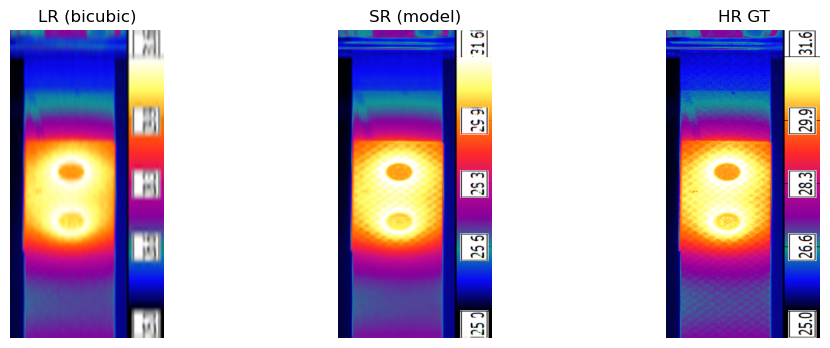

In [ ]:
import matplotlib.pyplot as plt
import torch

def tensor_to_image(t):
    img = t[0].detach().cpu()
    img = (img * 0.5) + 0.5
    if img.shape[0] == 1:
        img = img.squeeze(0)
        cmap = "gray"
    else:
        img = img.permute(1, 2, 0)
        cmap = None
    return img, cmap

batch = next(iter(srtrainer.dataloader))
srtrainer.model.eval()
srtrainer.model.set_input(batch)
with torch.no_grad():
    fake_hr = srtrainer.model.netG(batch["lr"].to(srtrainer.model.device))

lr_img, cmap_lr = tensor_to_image(batch["lr"])
fake_img, cmap_f = tensor_to_image(fake_hr)
hr_img, cmap_hr = tensor_to_image(batch["hr"])

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(lr_img, cmap=cmap_lr); plt.title("LR (bicubic)"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(fake_img, cmap=cmap_f); plt.title("SR (model)"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(hr_img, cmap=cmap_hr); plt.title("HR GT"); plt.axis("off")
plt.show()


## Test SR Model with Low-res Image

Testing on: Data\Low_resolution\CFRP_60_low\Record_2025-11-11_10-42-17.tiff


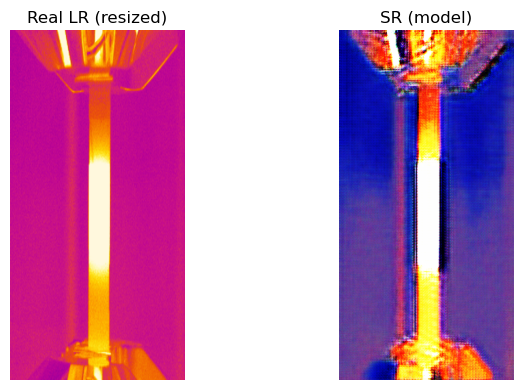

In [ ]:
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from torchvision import transforms

# match the size you trained on
HR_SIZE = (256, 512)

to_tensor = transforms.ToTensor()
normalize = transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])

def preprocess_real_lr(img_path):
    img = Image.open(img_path).convert("RGB")
    img_resized = img.resize(HR_SIZE, Image.BICUBIC)
    t = normalize(to_tensor(img_resized)).unsqueeze(0).to(device)  # [1,3,H,W]
    return img_resized, t

def tensor_to_img(t):
    t = t[0].detach().cpu()
    t = (t * 0.5) + 0.5
    if t.shape[0] == 1:
        return t.squeeze(0), "gray"
    else:
        return t.permute(1, 2, 0), None

sr_model = srtrainer.model   # assumes SRTrainer already run
sr_model.eval()
device = next(sr_model.netG.parameters()).device

# pick a low-res image
low_dir = Path("Data/Low_resolution/CFRP_60_low")
test_path = sorted(low_dir.glob("*"))[0]  # choose one file
print("Testing on:", test_path)

lr_pil, lr_tensor = preprocess_real_lr(test_path)
with torch.no_grad():
    sr_tensor = sr_model.netG(lr_tensor)

lr_img, cmap_lr = tensor_to_img(lr_tensor)
sr_img, cmap_sr = tensor_to_img(sr_tensor)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(lr_img, cmap=cmap_lr); plt.title("Real LR (resized)"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(sr_img, cmap=cmap_sr); plt.title("SR (model)"); plt.axis("off")
plt.tight_layout(); plt.show()
